# 0. Changing the Warning Level in Tensor

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 1. Creating a Model

In [2]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
# input

input = Input(shape =(28,28,1))

# 1st Conv Block

x = Conv2D (filters =64, kernel_size =3, padding ='same', activation='relu')(input)
x = Conv2D (filters =64, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 2nd Conv Block

x = Conv2D (filters =128, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =128, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 3rd Conv Block

x = Conv2D (filters =256, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =256, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =256, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)



x = Flatten()(x)
x = Dense(units = 64, activation ='relu')(x)
x = Dense(units = 64, activation ='relu')(x)
output = Dense(units = 10, activation ='softmax')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()




Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 64)        640       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 64)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 128)       147584    
                                                             

# 2. Loading the DataSet

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 3. Model Compiling

In [4]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

# 4. Fitting the Model -- Training

In [5]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=2,
    # We pass some validation for
    # monitoring validation loss and metrics
    # at the end of each epoch
    #validation_data=(x_val, y_val),
)

Fit model on training data
Epoch 1/2
938/938 [==============================] - 338s 359ms/step - loss: 0.6760 - sparse_categorical_accuracy: 0.9279
Epoch 2/2
938/938 [==============================] - 428s 457ms/step - loss: 0.0636 - sparse_categorical_accuracy: 0.9833


# 5. Evaluating on Test Data & Predicting

In [6]:
print("Evaluate on test data")
results = model.evaluate(x_test, y_test, batch_size=128)

Evaluate on test data
79/79 [==============================] - 13s 168ms/step - loss: 0.0802 - sparse_categorical_accuracy: 0.9781


In [7]:
predictions = model.predict(x_test)

313/313 [==============================] - 13s 42ms/step


In [8]:
import numpy

predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")      

matched numbers : 9781
non matched numbers : 219


# 6. Plotting Confusion Matrix

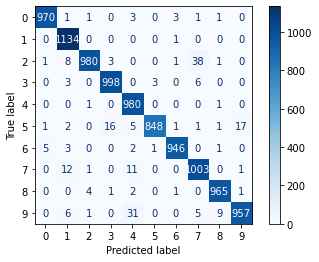

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_number
y_test = y_test
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.show()

# 7. Plotting the Roc Curve

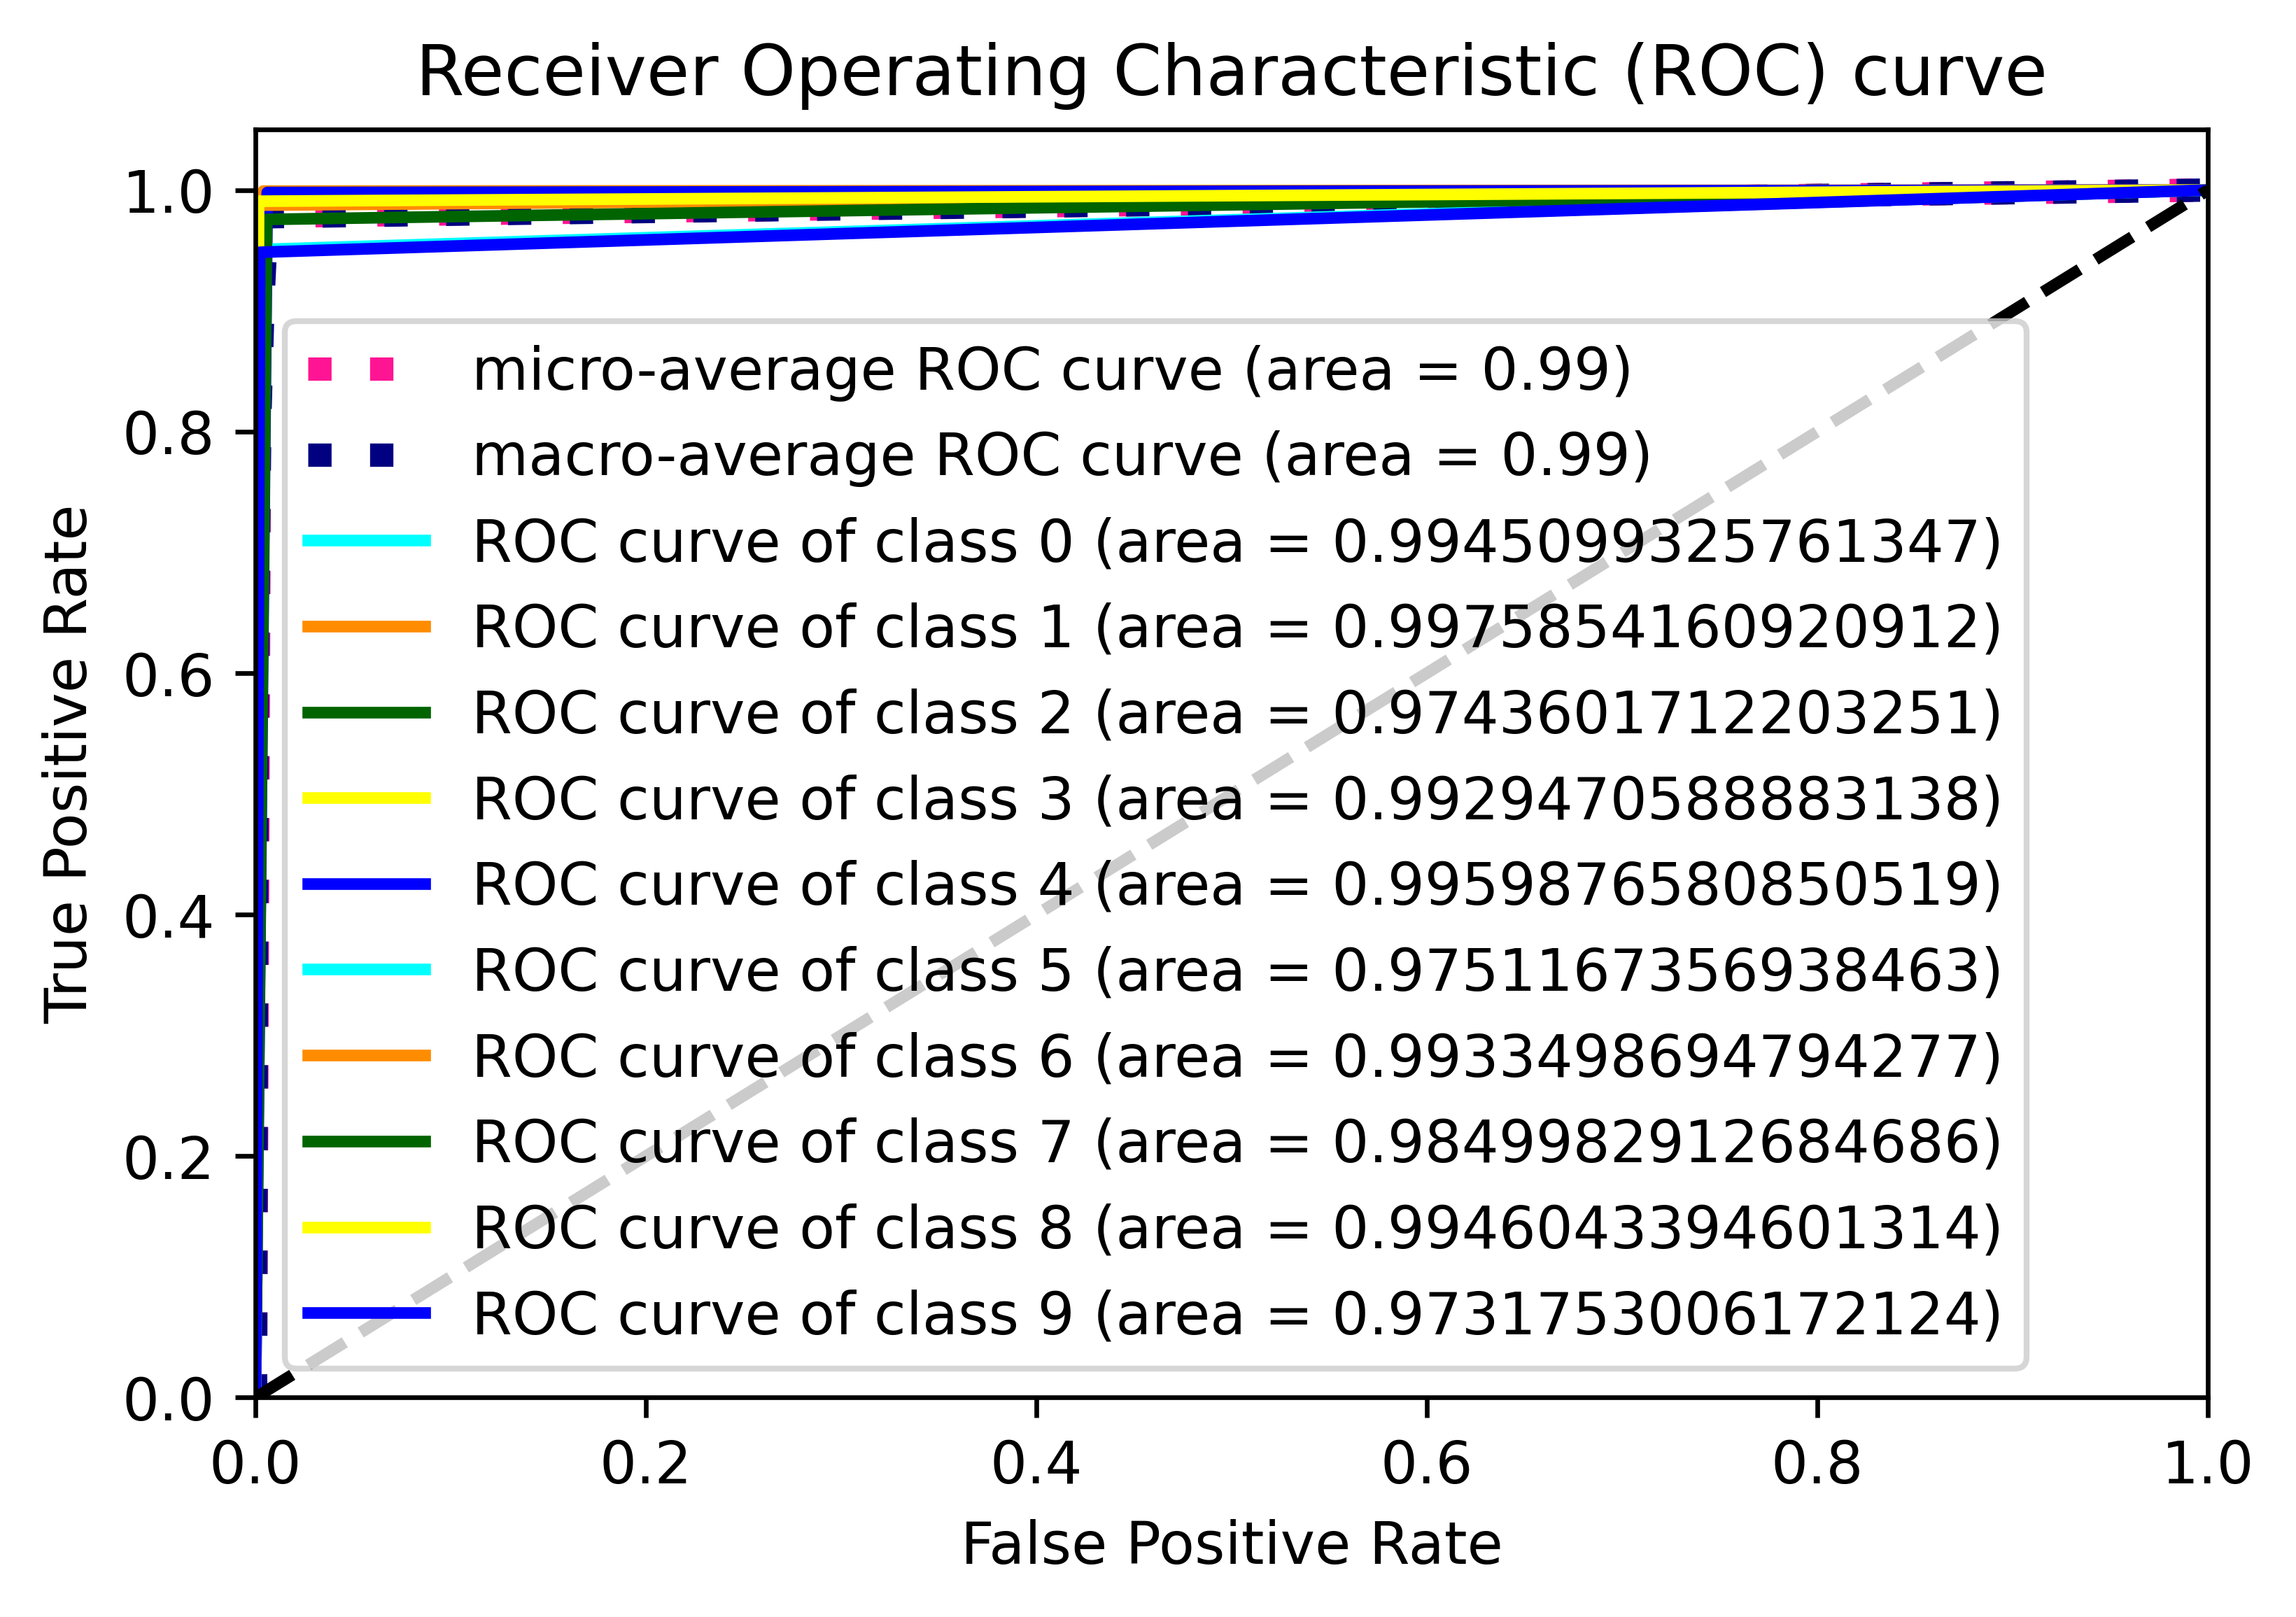

In [10]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2
plt.plot(fpr["micro"], tpr["micro"],
label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
color="deeppink", linestyle=":", linewidth=4,)

plt.plot(fpr["macro"], tpr["macro"],
label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
color="navy", linestyle=":", linewidth=4,)

colors = cycle(["aqua", "darkorange", "darkgreen", "yellow", "blue"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"ROC curve of class {i} (area = {roc_auc[i]})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.legend()